In [1]:
import numpy as np
from xso.parscans import run_xso_parscan, run_xso_stabilityscan

# --- 1. Run the IVP Scan ---
print("Running IVP scan...")
higherordermortality = np.linspace(0.005,0.04, 5)
ivp_param_values = [np.array([0, 0, 0, val]) for val in higherordermortality]
ivp_param_values2 = np.linspace(0.002,0.0055, 5)


ivp_results = run_xso_parscan(
    model_file_name='Stocketal2008',
    model_name='model',
    model_setup_name='model_setup_ivp', # <-- Your IVP setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,
    param_name2='N0__value',
    param_values2=ivp_param_values2,
    processes=20
)

if ivp_results is None:
    raise RuntimeError("IVP scan failed. Aborting.")

PROGRESS: Completed 5/5 outer points. (HigherOrderMortality__rate = [0.     0.     0.     0.0225]).

2D Scan complete. Total Time taken: 52.98125 seconds.


In [2]:

# --- 2. Calculate Mean of Last 1000 Steps ---
print("Calculating mean values for initial conditions...")
# Select variables and get the mean of the last 1000 time steps
mean_results = ivp_results[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')

print(mean_results)



Calculating mean values for initial conditions...
<xarray.Dataset> Size: 2kB
Dimensions:                     (N0__value: 5, HigherOrderMortality__rate: 5,
                                 phyto: 3, zoo: 4)
Coordinates:
  * HigherOrderMortality__rate  (HigherOrderMortality__rate) float64 40B 0.00...
  * N0__value                   (N0__value) float64 40B 0.002 ... 0.0055
  * phyto                       (phyto) float64 24B 0.63 6.3 63.0
  * zoo                         (zoo) float64 32B 6.3 63.0 630.0 6.3e+03
Data variables:
    Nutrient__value             (N0__value, HigherOrderMortality__rate) float64 200B ...
    Phytoplankton__biomass      (N0__value, HigherOrderMortality__rate, phyto) float64 600B ...
    Zooplankton__biomass        (N0__value, HigherOrderMortality__rate, zoo) float64 800B ...


In [4]:

# --- 3. Define the Initial Value Mapping ---
# Maps: {Variable name in mean_results} -> {Parameter name in model_setup_stability}
iv_map = {
    'Nutrient__value': 'Nutrient__value_init',
    'Phytoplankton__biomass':'Phytoplankton__biomass_init',
    'Zooplankton__biomass':'Zooplankton__biomass_init'
}

# --- 4. Run the Stability Scan ---
print("Running stability scan with dynamic initial values...")
stability_results = run_xso_stabilityscan(
    model_file_name='Stocketal2008',
    model_setup_name='model_setup_stability', # <-- Your stability setup
    param_name='HigherOrderMortality__rate',
    param_values=ivp_param_values,       # Must be the same parameter range
    param_name2='N0__value',
    param_values2=ivp_param_values2,     # Must be the same parameter range
    processes=20,
    initial_values_ds=mean_results,      # <-- Pass the mean results
    iv_mapping=iv_map                    # <-- Pass the name mapping
)

# Display the final result
if stability_results is not None:
    print("\nFinal Stability Scan Output Dataset:")
    print(stability_results)
    print("\nStability data:")
    print(stability_results['stability'])

PROGRESS: Completed 5/5 outer points. (HigherOrderMortality__rate = [0.      0.      0.      0.03125]).

2D Stability Scan complete. Total Time taken: 5.13149 seconds.

Final Stability Scan Output Dataset:
<xarray.Dataset> Size: 44kB
Dimensions:                                         (N0__value: 5,
                                                     HigherOrderMortality__rate: 5,
                                                     zoo: 4, time: 2, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 16B 0.0 1.0
  * zoo                               

In [6]:
import matplotlib.pyplot as plt
import numpy as np

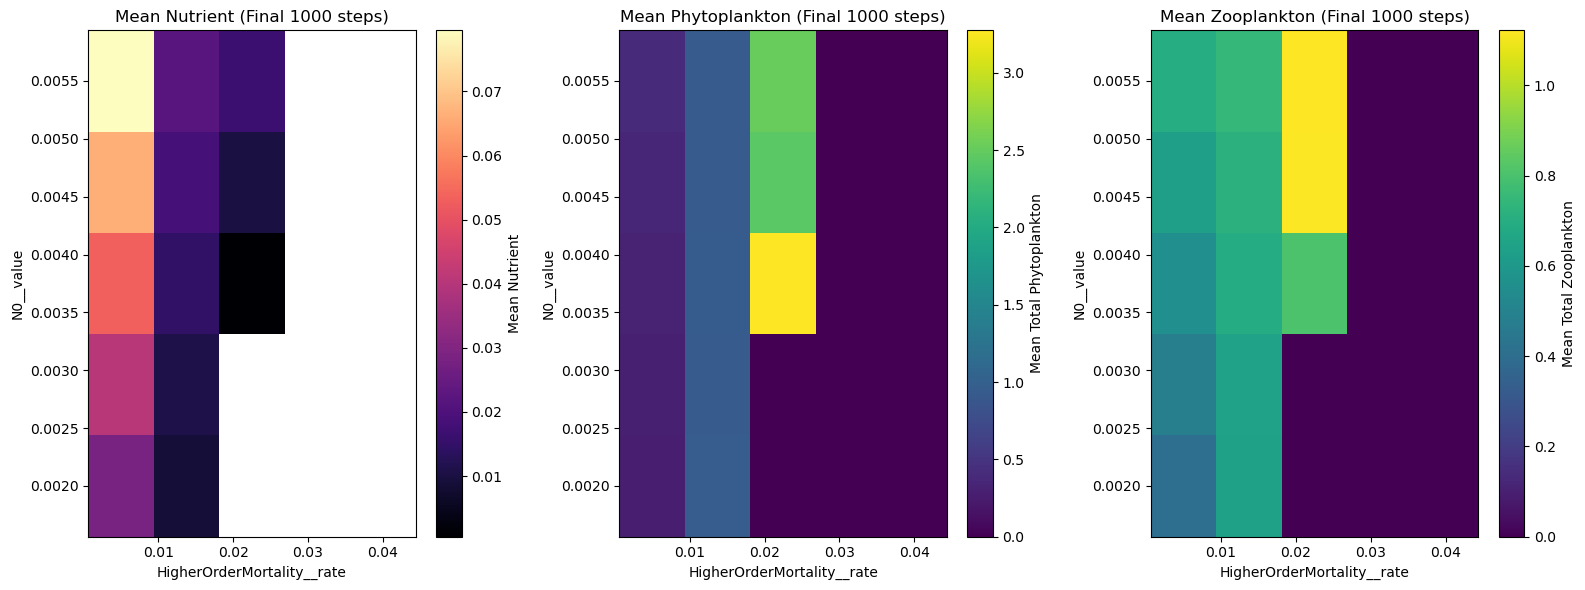

In [9]:
# Assuming 'mean_results' is your dataset with mean values
# and has variables 'Phytoplankton__biomass' and 'Nutrient__value'

# Create a figure with two subplots, side-by-side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))


# Plot 2: Nutrient mean value
mean_results['Nutrient__value'].plot(
    ax=ax1,
    cmap='magma',
    cbar_kwargs={'label': 'Mean Nutrient'}
)
ax1.set_title('Mean Nutrient (Final 1000 steps)')

# Plot 1: Phytoplankton mean value
# We sum over the 'phyto' dimension to get a single 2D value
mean_results['Phytoplankton__biomass'].sum(dim='phyto').plot(
    ax=ax2,
    cmap='viridis',  # 'cmap' sets the colormap
    cbar_kwargs={'label': 'Mean Total Phytoplankton'}
)
ax2.set_title('Mean Phytoplankton (Final 1000 steps)')


mean_results['Zooplankton__biomass'].sum(dim='zoo').plot(
    ax=ax3,
    cmap='viridis',  # 'cmap' sets the colormap
    cbar_kwargs={'label': 'Mean Total Zooplankton'}
)
ax3.set_title('Mean Zooplankton (Final 1000 steps)')

plt.tight_layout()
plt.show()

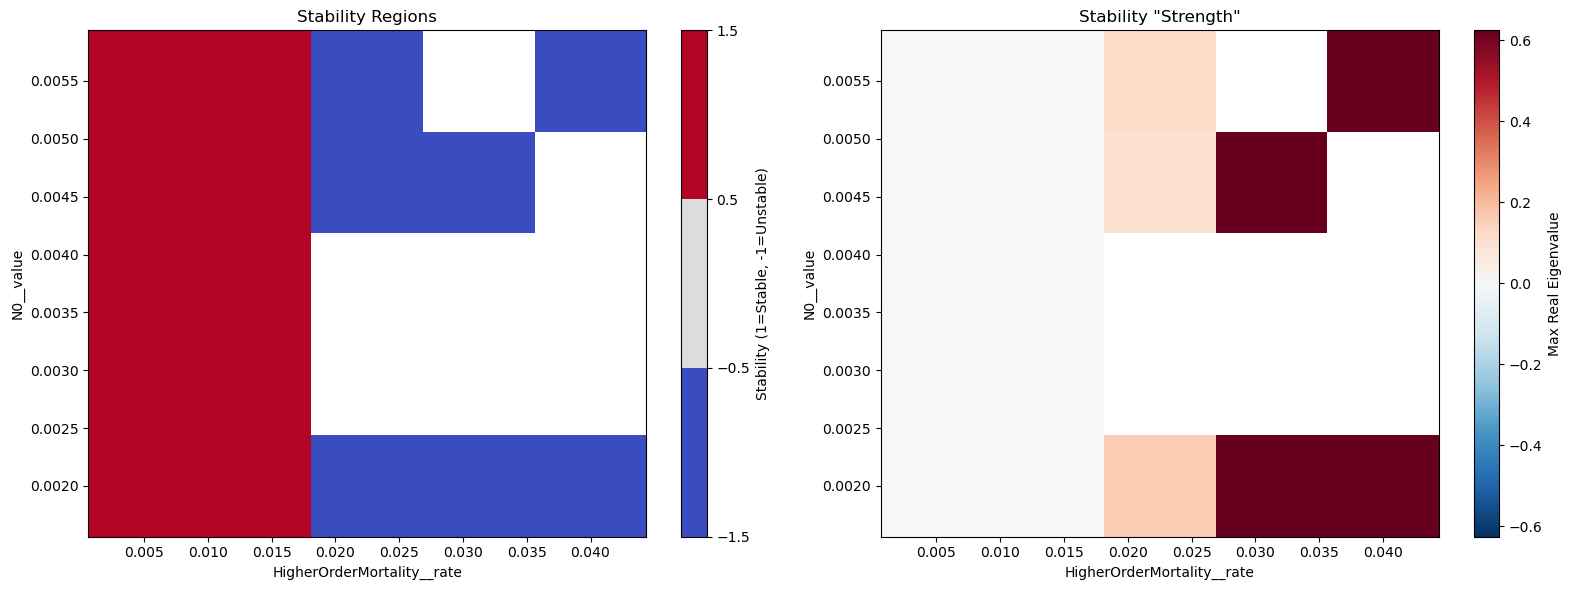

In [13]:
import xarray as xr
if stability_results is not None:
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- HIGHLIGHTED FIX ---
    # Change 1, -1, 0 to 1.0, -1.0, 0.0
    stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
    # --- END FIX ---
    
    # Use .map() to apply the mapping
    numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan), 
                                     stability_results['stability'], 
                                     vectorize=True)
    
    numeric_stability.plot(
        ax=ax1,
        cmap='coolwarm',  # Red-Blue map
        levels=[-1.5, -0.5, 0.5, 1.5], # Bins for -1, 0, 1
        cbar_kwargs={'label': 'Stability (1=Stable, -1=Unstable)'}
    )
    ax1.set_title('Stability Regions')

    # Plot 2: The 'max_eigenvalue'
    # This plot was already correct
    stability_results['max_eigenvalue'].plot(
        ax=ax2,
        cmap='RdBu_r',  # Red-Blue diverging map
        center=0,       # Center the colormap at 0
        cbar_kwargs={'label': 'Max Real Eigenvalue'}
    )
    ax2.set_title('Stability "Strength"')

    plt.tight_layout()
    plt.show()

Plotting 'x' markers at 8 non-meaningful locations.


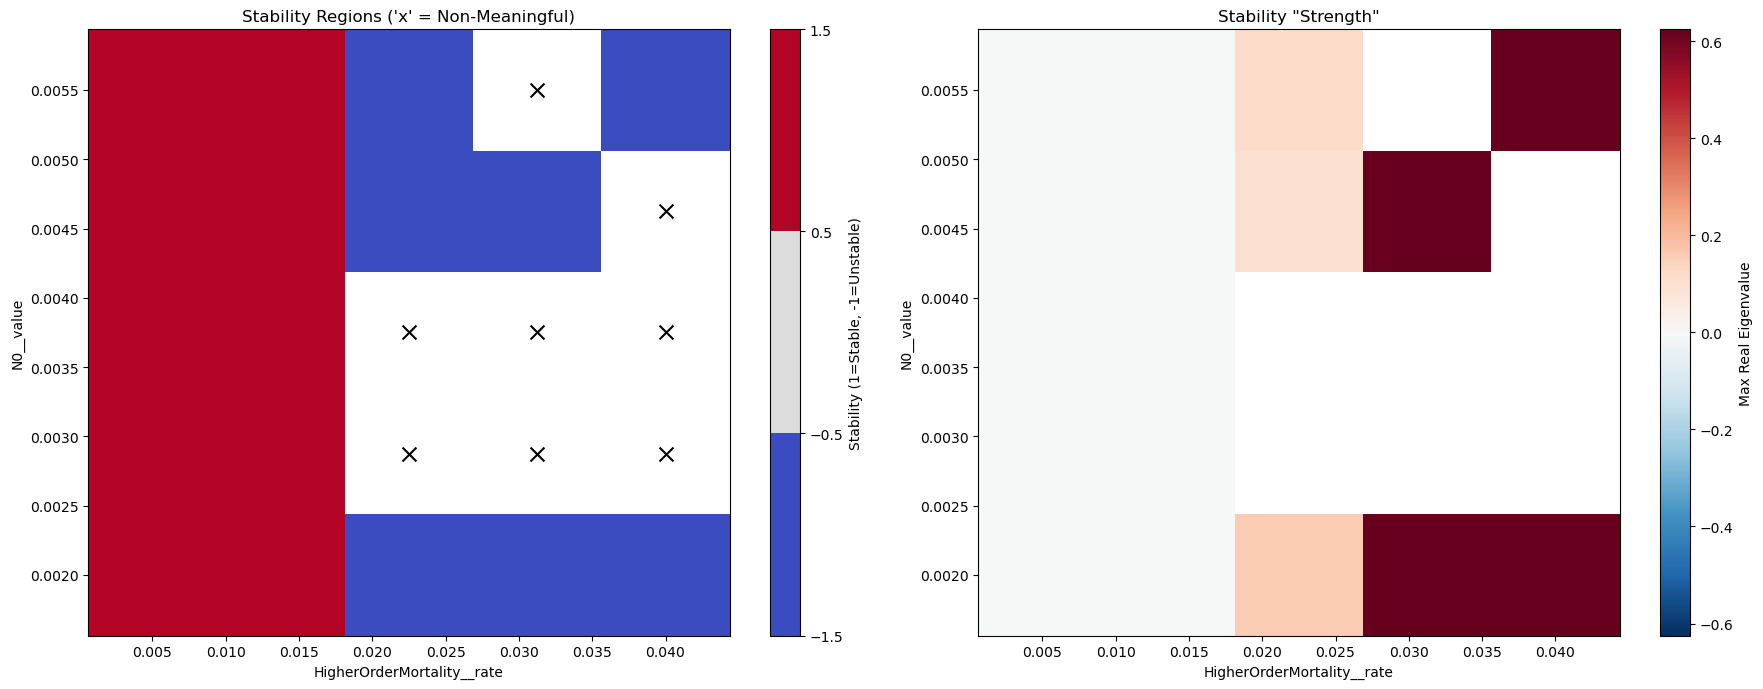

In [25]:
# --- HIGHLIGHTED FIX: Check for the 'None' object, not the string "None" ---
if stability_results is not None:
    # --- 1. CREATE THE BASE STABILITY PLOT ---
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
    numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan), 
                                     stability_results['stability'], 
                                     vectorize=True)
    
    numeric_stability.plot(
        ax=ax1,
        cmap='coolwarm',
        levels=[-1.5, -0.5, 0.5, 1.5],
        cbar_kwargs={'label': 'Stability (1=Stable, -1=Unstable)'},
        zorder=1
    )

    # --- 2. CREATE THE "MEANINGFUL STATE" MASK ---
    
    steady_state = stability_results.isel(time=-1)
    threshold = 1e-6 
    
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    
    meaningful_mask = phyto_ok & zoo_ok & nutrient_ok
    non_meaningful_overlay = xr.where(meaningful_mask, np.nan, 1.0)

    # --- 3. ADD THE 'X' MARKER OVERLAY (ROBUST METHOD) ---
    
    # Find the indices of the cells to plot
    y_indices, x_indices = np.where(np.isfinite(non_meaningful_overlay.values))
    
    if len(x_indices) > 0:
        # Get the coordinate *values* at those indices
        x_coords = non_meaningful_overlay['HigherOrderMortality__rate'].values[x_indices]
        y_coords = non_meaningful_overlay['N0__value'].values[y_indices]
        
        # Use matplotlib's scatter directly
        ax1.scatter(
            x_coords, 
            y_coords, 
            marker='x', 
            color='black', 
            s=100,  # Adjust size as needed
            zorder=2
        )
        print(f"Plotting 'x' markers at {len(x_indices)} non-meaningful locations.")
    else:
        print("All steady states are ecologically meaningful. No 'x' markers to plot.")

    ax1.set_title("Stability Regions ('x' = Non-Meaningful)")

    # --- 4. PLOT MAX EIGENVALUE (UNCHANGED) ---
    
    stability_results['max_eigenvalue'].plot(
        ax=ax2,
        cmap='RdBu_r',
        center=0,
        cbar_kwargs={'label': 'Max Real Eigenvalue'}
    )
    ax2.set_title('Stability "Strength"')

    plt.tight_layout()
    plt.show()

In [23]:
non_meaningful_overlay

<xarray.DataArray (N0__value: 5, HigherOrderMortality__rate: 5)> Size: 200B
array([[nan, nan, nan, nan, nan],
       [nan, nan,  1.,  1.,  1.],
       [nan, nan,  1.,  1.,  1.],
       [nan, nan, nan, nan,  1.],
       [nan, nan, nan,  1., nan]])
Coordinates:
  * HigherOrderMortality__rate  (HigherOrderMortality__rate) float64 40B 0.00...
  * N0__value                   (N0__value) float64 40B 0.002 ... 0.0055
    time                        float64 8B 1.0

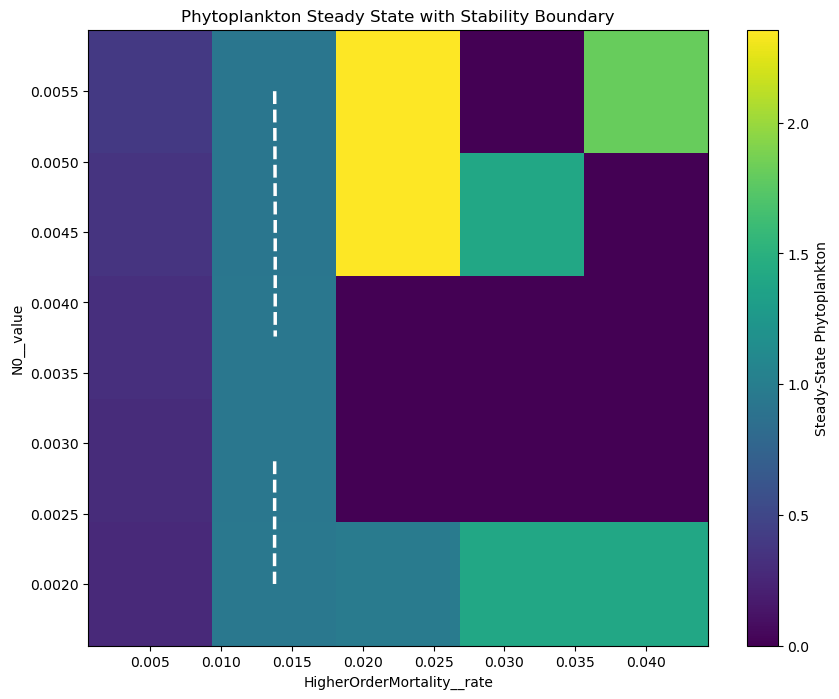

In [26]:
if stability_results is not None:
    plt.figure(figsize=(10, 8))

    # --- HIGHLIGHTED FIX ---
    # 1. Select the steady-state (the *final* time step)
    #    Then sum over the 'phyto' dimension
    steady_phyto = stability_results['Phytoplankton__biomass'].isel(time=-1).sum(dim='phyto')
    # --- END FIX ---
    
    steady_phyto.plot(
        cmap='viridis',
        cbar_kwargs={'label': 'Steady-State Phytoplankton'}
    )

    # 2. Overlay the stability boundary (this part was correct)
    stability_results['max_eigenvalue'].plot.contour(
        levels=[0],      # Only draw the contour at the 0-level
        colors='white',  # Make the line white
        linewidths=2.5,
        linestyles='--'   # Make the line dashed
    )

    plt.title('Phytoplankton Steady State with Stability Boundary')
    plt.show()

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import random

def plot_exemplary_timeseries(ivp_results, stability_results):
    """
    Finds and plots random example time-series from the ivp_results
    that correspond to stable, unstable, and washout steady states.

    Parameters
    ----------
    ivp_results : xarray.Dataset
        The 4D dataset from your 'run_xso_parscan' (time-series).
    stability_results : xarray.Dataset
        The 4D dataset from 'run_xso_stabilityscan' (stability map).
    """
    
    print("Finding exemplary time-series...")

    # --- 1. Re-create the masks from Plot 2 ---
    
    # Create numeric stability map
    stability_map = {'stable': 1.0, 'unstable': -1.0, 'marginal': 0.0, np.nan: np.nan}
    numeric_stability = xr.apply_ufunc(lambda x: stability_map.get(x, np.nan), 
                                     stability_results['stability'], 
                                     vectorize=True)
    
    # Create meaningful/washout mask
    steady_state = stability_results.isel(time=-1)
    threshold = 1e-6 
    phyto_ok = steady_state['Phytoplankton__biomass'].all(dim='phyto') > threshold
    zoo_ok = steady_state['Zooplankton__biomass'].all(dim='zoo') > threshold
    nutrient_ok = steady_state['Nutrient__value'] > threshold
    meaningful_mask = phyto_ok & zoo_ok & nutrient_ok

    # --- 2. Define the three category masks ---
    
    # Category 1: Stable AND meaningful (not washout)
    stable_mask = (numeric_stability == 1.0) & (meaningful_mask == True)
    
    # Category 2: Unstable AND meaningful (not washout)
    unstable_mask = (numeric_stability == -1.0) & (meaningful_mask == True)
    
    # Category 3: Washout (non-meaningful)
    washout_mask = (meaningful_mask == False)
    
    # --- 3. Helper function to get a random sample ---
    
    def _get_random_selector(mask):
        """Finds all points in a mask and returns a random one."""
        # Get coordinate names, e.g., ('N0__value', 'HigherOrderMortality__rate')
        dim1, dim2 = mask.dims
        
        # Get the 2D indices (y, x) of all 'True' points
        y_indices, x_indices = np.where(mask.values)
        
        if len(x_indices) == 0:
            return None, None  # No points found for this category
        
        # Pick one random index from the list of found points
        rand_idx = random.choice(range(len(x_indices)))
        sample_x_idx = x_indices[rand_idx]
        sample_y_idx = y_indices[rand_idx]
        
        # Get the coordinate *values* at that index
        p1_val = mask[dim2].values[sample_x_idx]
        p2_val = mask[dim1].values[sample_y_idx]
        
        # This is the dictionary we use with .sel()
        selector = {dim1: p2_val, dim2: p1_val}
        
        # Create a title for the plot
        title_str = f"{dim1}={p2_val:.4f}, {dim2}={p1_val:.4f}"
        
        return selector, title_str

    # --- 4. Get the three random selectors ---
    stable_sel, stable_title = _get_random_selector(stable_mask)
    unstable_sel, unstable_title = _get_random_selector(unstable_mask)
    washout_sel, washout_title = _get_random_selector(washout_mask)
    
    # --- 5. Create the plot ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
    
    # Plot 1: Stable
    if stable_sel:
        ts = ivp_results.sel(stable_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[0], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[0], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[0], label='Nutrient')
        axes[0].set_title(f"Example 1: Stable & Meaningful\n({stable_title})")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[0].set_title("No 'Stable & Meaningful' points found")

    # Plot 2: Unstable
    if unstable_sel:
        ts = ivp_results.sel(unstable_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[1], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[1], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[1], label='Nutrient')
        axes[1].set_title(f"Example 2: Unstable & Meaningful (Likely Oscillations)\n({unstable_title})")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[1].set_title("No 'Unstable & Meaningful' points found")

    # Plot 3: Washout
    if washout_sel:
        ts = ivp_results.sel(washout_sel)
        ts['Phytoplankton__biomass'].sum(dim='phyto').plot.line(x='time', ax=axes[2], label='Total Phyto')
        ts['Zooplankton__biomass'].sum(dim='zoo').plot.line(x='time', ax=axes[2], label='Total Zoo')
        ts['Nutrient__value'].plot.line(x='time', ax=axes[2], label='Nutrient')
        axes[2].set_title(f"Example 3: Washout / Non-Meaningful\n({washout_title})")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[2].set_title("No 'Washout' points found")
        
    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

Finding exemplary time-series...


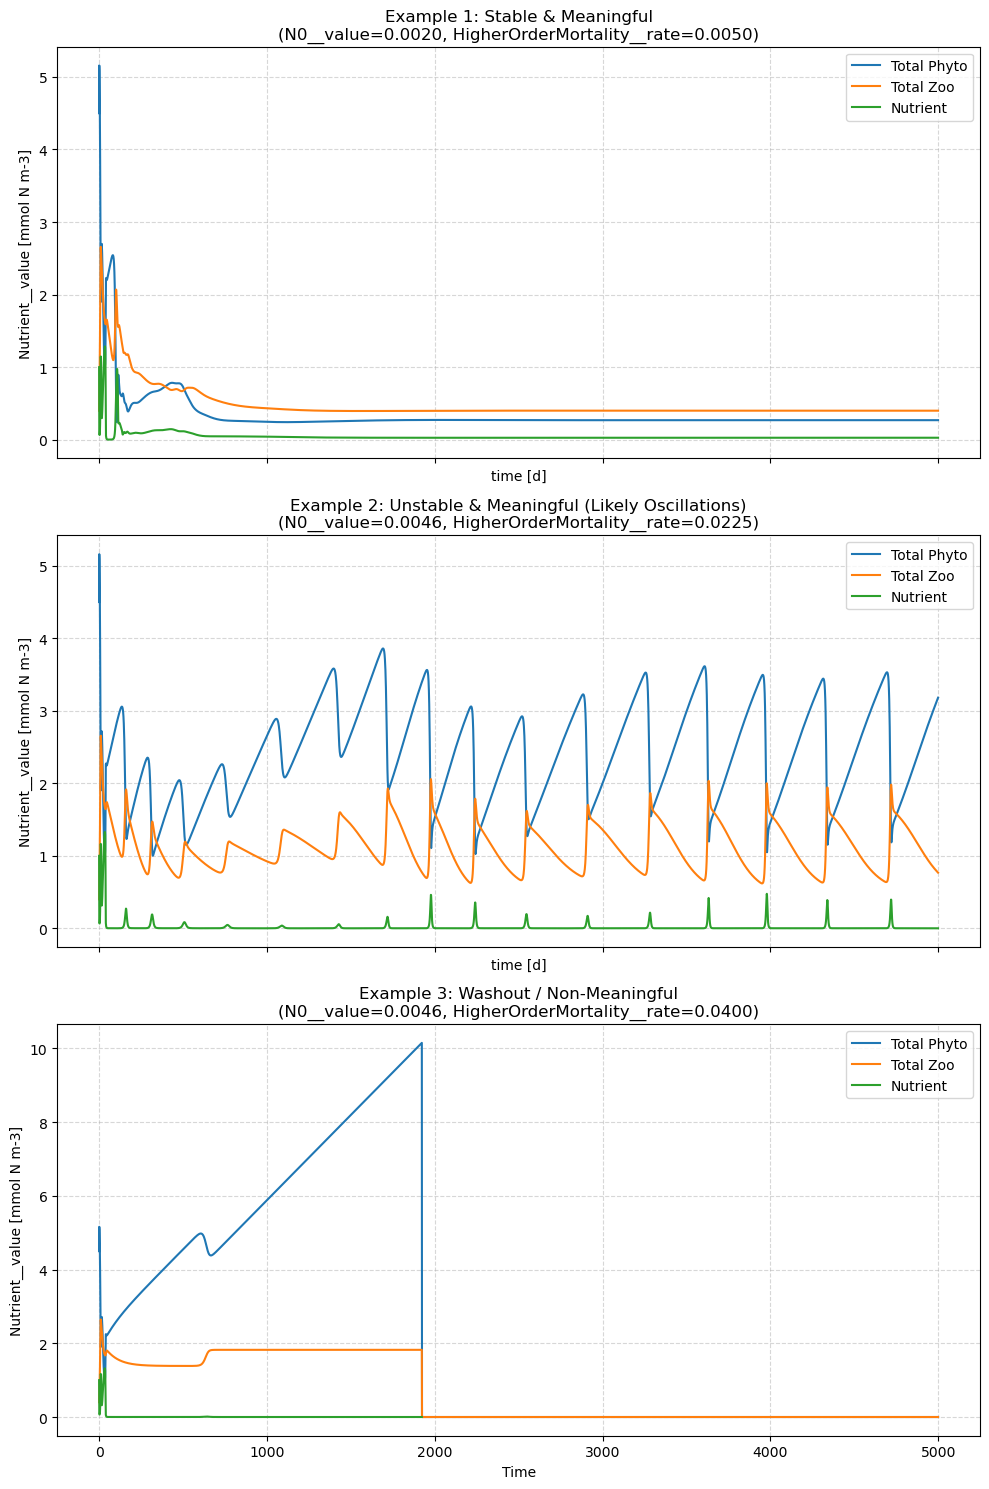

In [29]:
# Assuming you have:
# ivp_results (from run_xso_parscan)
# stability_results (from run_xso_stabilityscan)

plot_exemplary_timeseries(ivp_results, stability_results)